In [5]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import keras
from keras import layers

# Cell 2: Loading the data
X, y = fetch_openml("adult", version=2, as_frame=True, return_X_y=True)
print("Rows and columns:", X.shape)
print("Target values:", y.value_counts().to_dict())

# Cell 3: Encoding the target
y = LabelEncoder().fit_transform(y)
print("Positive rate (share earning >50K):", round(y.mean(), 3))

# Cell 4: Train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training rows:", X_train.shape[0])
print("Test rows:    ", X_test.shape[0])

# Cell 5: Numeric and categorical columns
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

print("Numeric features:    ", numeric_features)
print("Categorical features:", categorical_features)

Rows and columns: (48842, 14)
Target values: {'<=50K': 37155, '>50K': 11687}
Positive rate (share earning >50K): 0.239
Training rows: 39073
Test rows:     9769
Numeric features:     ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


CV F1 Mean: 0.658
CV F1 Standard Deviation: 0.010
Logistic Regression Accuracy: 0.852
Logistic Regression F1 Score: 0.656


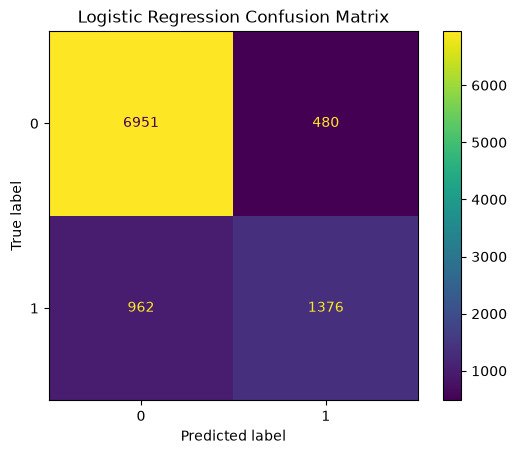

In [6]:
# Cell 6: Build the preprocessor
numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess = ColumnTransformer(transformers=[
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
])

# Cell 7: The full pipeline
clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

# Cell 8: Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='f1')

print(f"CV F1 Mean: {cv_scores.mean():.3f}")
print(f"CV F1 Standard Deviation: {cv_scores.std():.3f}")

# Cell 9: Fit and evaluate on the test set
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

clf_acc = accuracy_score(y_test, y_pred)
clf_f1 = f1_score(y_test, y_pred)

print(f"Logistic Regression Accuracy: {clf_acc:.3f}")
print(f"Logistic Regression F1 Score: {clf_f1:.3f}")

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
disp.ax_.set_title("Logistic Regression Confusion Matrix")
plt.show()

### Prediction
I expect the neural network to perform similarly to, or only slightly better than, the logistic regression model. While neural networks can capture complex, non-linear relationships, structured tabular datasets like this one often perform extremely well with classical linear models. The difference in the F1 score should be relatively small.

Training array shape: (39073, 105)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │           6,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,897 (34.75 KB)

 Trainable params: 8,897 (34.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8187 - loss: 0.3741 - val_accuracy: 0.8501 - val_loss: 0.3296
Epoch 2/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8498 - loss: 0.3210 - val_accuracy: 0.8536 - val_loss: 0.3283
Epoch 3/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8526 - loss: 0.3144 - val_accuracy: 0.8516 - val_loss: 0.3283
Epoch 4/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8550 - loss: 0.3113 - val_accuracy: 0.8529 - val_loss: 0.3297
Epoch 5/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8558 - loss: 0.3086 - val_accuracy: 0.8521 - val_loss: 0.3308
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Neural Network Accuracy: 0.858
Neural Network F1 Score: 0.679


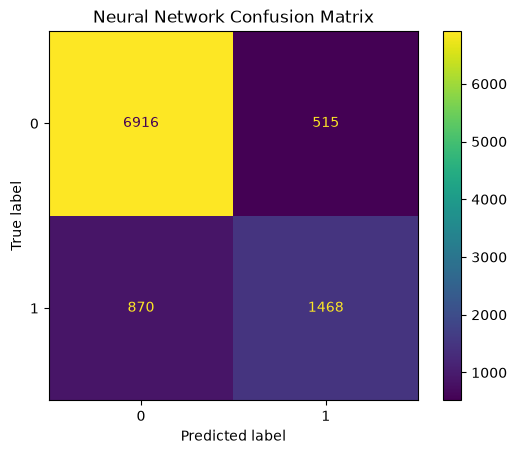

MODEL COMPARISON
Logistic Regression -> F1 Score: 0.656 | Accuracy: 0.852
Neural Network      -> F1 Score: 0.679 | Accuracy: 0.858


In [7]:
# Cell 10: Transform data for Neural Network
X_train_prep = preprocess.fit_transform(X_train)
X_test_prep  = preprocess.transform(X_test)
print("Training array shape:", X_train_prep.shape)

# Cell 11: Build the network
keras.utils.set_random_seed(42)

net = keras.Sequential([
    layers.Input(shape=(X_train_prep.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

net.summary()

# Cell 12: Compile and train
net.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=3, 
    restore_best_weights=True
)

history = net.fit(
    X_train_prep, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    callbacks=[early_stop]
)

# Cell 13: Evaluate Neural Network on the test set
nn_prob = net.predict(X_test_prep).ravel()
nn_pred = (nn_prob > 0.5).astype(int)

nn_acc = accuracy_score(y_test, nn_pred)
nn_f1 = f1_score(y_test, nn_pred)

print(f"Neural Network Accuracy: {nn_acc:.3f}")
print(f"Neural Network F1 Score: {nn_f1:.3f}")

disp_nn = ConfusionMatrixDisplay.from_predictions(y_test, nn_pred)
disp_nn.ax_.set_title("Neural Network Confusion Matrix")
plt.show()

# Cell 14: The comparison
print("="*45)
print("MODEL COMPARISON")
print("="*45)
print(f"Logistic Regression -> F1 Score: {clf_f1:.3f} | Accuracy: {clf_acc:.3f}")
print(f"Neural Network      -> F1 Score: {nn_f1:.3f} | Accuracy: {nn_acc:.3f}")
print("="*45)

In [8]:
# Cell 15: Side-by-Side Comparison
print("="*45)
print("MODEL COMPARISON")
print("="*45)
print(f"Logistic Regression -> F1 Score: {clf_f1:.3f} | Accuracy: {clf_acc:.3f}")
print(f"Neural Network      -> F1 Score: {nn_f1:.3f} | Accuracy: {nn_acc:.3f}")
print("="*45)

MODEL COMPARISON
Logistic Regression -> F1 Score: 0.656 | Accuracy: 0.852
Neural Network      -> F1 Score: 0.679 | Accuracy: 0.858


### Ethical considerations
There is a significant risk of entrenching existing inequalities, as this dataset contains sensitive attributes like sex, race, and nationality. In this specific scenario, a false positive (wrongly predicting someone has a high income) could exclude a vulnerable household from a much-needed benefit program. Given these high stakes, a simpler and transparent model like Logistic Regression is highly preferable to an opaque neural network, as its decisions can be easily explained and audited for biases.

## Wrapping up

The Neural Network achieved a higher F1 score (0.679) compared to the Logistic Regression model (0.656), showing a marginal improvement of 0.023. Overall accuracy led to the same conclusion, with the neural network slightly outperforming the classical model (0.858 vs. 0.852). Accuracy alone is highly insufficient for this dataset because the target variable is imbalanced (only ~23.9% earn >50K); a naive model could achieve around 76% accuracy simply by predicting everyone belongs to the lower-income class. The confusion matrices indicate the Neural Network identified the higher-income class slightly more successfully, yielding a better trade-off between false positives and false negatives. Despite this, the extra complexity, increased computational cost, and loss of interpretability are arguably not worth it for a mere 2.3% improvement in the F1 score. The network likely performed slightly better due to its multi-layered architecture, which can automatically capture complex non-linear relationships and interactions between the mixed tabular features, whereas the rigid linear nature of logistic regression limits its predictive boundaries.